Số dòng dữ liệu để clustering: 30341
Các feature sử dụng: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed']



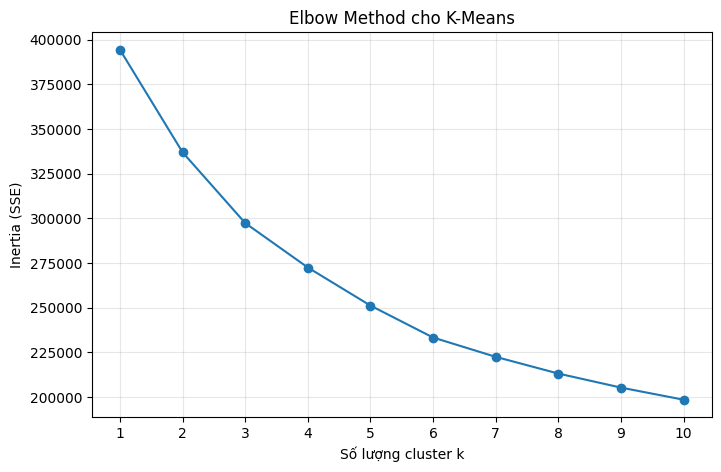

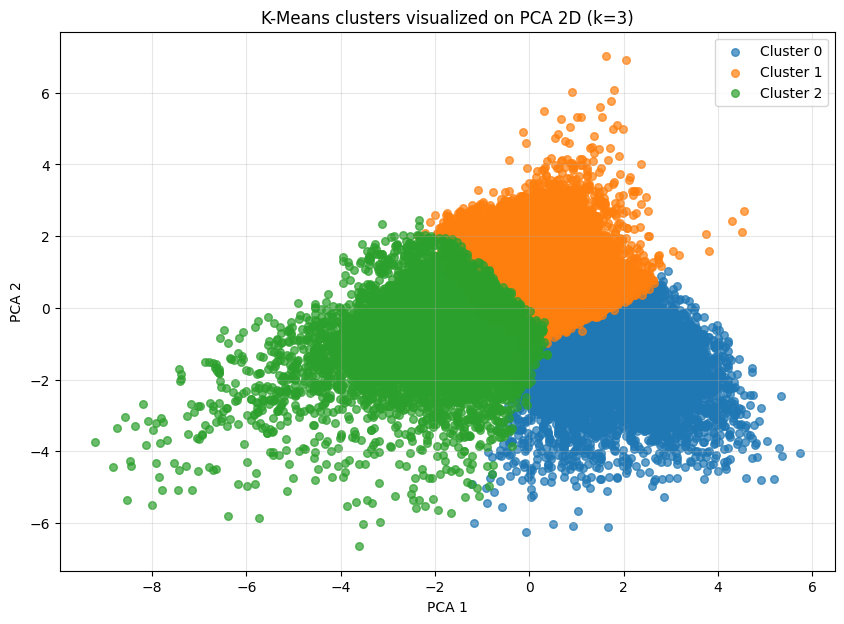



CLUSTER CENTROIDS (original scale):
             co    no2      o3    pm10   pm25    so2  clouds  precipitation  pressure  relative_humidity  temperature  uv_index  wind_speed
cluster                                                                                                                                    
0        189.55  13.49  112.73   54.48  41.09  73.97   57.23           0.11   1007.43              61.03        29.81      3.60        2.04
1        460.91  24.48   41.63   46.28  34.07  47.15   71.87           0.41   1006.74              86.00        26.23      0.64        1.77
2        360.76  43.35   42.22  117.60  84.78  79.86   79.86           0.08   1017.46              76.37        19.04      0.72        1.59


CLUSTER PROFILE REPORT:
            co                                 no2                               o3                              pm10                              pm25                              so2                           clouds                   

NameError: name 'davies_bouldin_score' is not defined

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dữ liệu đã làm sạch
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv', low_memory=False, on_bad_lines='skip')
except Exception as e:
    print(f"Error reading cleaned file: {e}")
    files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv', '../data_raw/2025.csv']
    df_list = []
    for f in files:
        try:
            df_list.append(pd.read_csv(f, low_memory=False, on_bad_lines='skip'))
        except:
            pass
    df = pd.concat(df_list, ignore_index=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}

# Chọn các đặc trưng số để clustering (giống hệt PCA)
feature_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
               'precipitation', 'pressure', 'relative_humidity', 
               'temperature', 'uv_index', 'wind_speed']
X = df[feature_cols].dropna()

print(f"Số dòng dữ liệu để clustering: {len(X)}")
print(f"Các feature sử dụng: {feature_cols}\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
ks = list(range(1, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertia, marker='o')
plt.xticks(ks)
plt.xlabel('Số lượng cluster k')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method cho K-Means')
plt.grid(alpha=0.3)
plt.show()
print('\n' + '='*80 + '\n')

# K-Means clustering
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# PCA 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
palette = sns.color_palette('tab10', n_colors=k_opt)
for cluster_id in sorted(np.unique(labels)):
    mask = labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[cluster_id]], s=30, alpha=0.7, label=f'Cluster {cluster_id}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'K-Means clusters visualized on PCA 2D (k={k_opt})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print('\n' + '='*80 + '\n')

# Cluster profile report
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns
)
cluster_centers.index.name = 'cluster'
print('CLUSTER CENTROIDS (original scale):')
print(cluster_centers.round(2))
print('\n' + '='*80 + '\n')

clustered_df = df.loc[X.index].copy()
clustered_df['cluster'] = labels

profile_report = clustered_df.groupby('cluster')[feature_cols].agg(['count', 'mean', 'std', 'min', 'max'])
print('CLUSTER PROFILE REPORT:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    print(profile_report.round(2).to_string())
print('\n' + '='*80 + '\n')

# Calculate clustering metrics (memory efficient)
# Silhouette Score on sample to avoid MemoryError
sil_score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
db_score = davies_bouldin_score(X_scaled, labels)
ch_score = calinski_harabasz_score(X_scaled, labels)
print(f'Silhouette Score (on 5000 sample): {sil_score:.3f} (higher is better, range: [-1, 1])')
print(f'Davies-Bouldin Index: {db_score:.3f} (lower is better)')
print(f'Calinski-Harabasz Index: {ch_score:.2f} (higher is better)')
print(profile_report.round(2).to_string())
print('\n' + '='*80 + '\n')


# Prepare hour, month, season
if 'hour' not in clustered_df.columns and 'date' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['date'].dt.hour
if 'month' not in clustered_df.columns and 'date' in clustered_df.columns:
    clustered_df['month'] = clustered_df['date'].dt.month
# Data đã có cột 'season', chỉ cần map tên mùa
if 'season' in clustered_df.columns:
    clustered_df['season_name'] = clustered_df['season'].map(SEASON_MAP)
print('CLUSTER SIZE:')
print(clustered_df['cluster'].value_counts().sort_index())
print()

if 'aqi' in clustered_df.columns:
    print('MEAN AQI BY CLUSTER:')
    print(clustered_df.groupby('cluster')['aqi'].agg(['mean', 'std', 'min', 'max']).round(2))
    print()

if 'season_name' in clustered_df.columns:
    print('CLUSTER DISTRIBUTION BY SEASON:')
    print(clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0))
    print()

if 'hour' in clustered_df.columns:
    print('CLUSTER DISTRIBUTION BY HOUR (tóm tắt):')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    top_hours = hour_counts.idxmax(axis=1)
    print('Hour with most members in each cluster:')
    print(top_hours)
    print()

if 'aqi' in clustered_df.columns:
    print('CLUSTERS RANKED BY MEAN AQI:')
    aqi_cluster = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print(aqi_cluster.round(2))

In [ ]:
import pandas as pd

# Show full table output instead of truncated notebook display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season (full table):')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour (full table):')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours.to_string())

if 'aqi' in clustered_df.columns:
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2).to_string())


Cluster distribution by season (full table):
season_name    Hè   Thu  Xuân  Đông
cluster                            
0            4383  3163  5199  3695
1             114  1117  1538  2631
2            2847  2273  2098  1283

Cluster distribution by hour (full table):
hour      0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
cluster                                                                                                                        
0        930  949  959  950  965  933  917  934  851  706  566  447  367  307  306  323  339  377  481  616  681  765  875  896
1        276  264  266  272  254  281  300  274  284  246  190  181  153  113  107  101   88  121  191  265  298  312  275  288
2         63   51   39   42   45   50   47   56  129  312  508  636  744  844  851  840  837  766  592  383  285  187  114   80

Hour with most members in each cluster:
cluster
0     4
1    21
2    14

Clusters ranked 